# Notebook 1: PV-Wetterdaten Schweiz

Dieses Notebook lädt die PVOUT-Solardaten (Global Solar Atlas v2), prüft ihre Qualität,  
berechnet den mittleren PV-Ertrag pro Gemeinde und speichert das Ergebnis als CSV.  
Am Ende kann eine beliebige Schweizer Adresse eingegeben werden, um den PVOUT-Wert direkt abzulesen.

**PVOUT (PV Power Output)** = kWh pro kWp installierter Leistung und Jahr.  
Beispiel: PVOUT 1200 bedeutet, eine 5-kWp-Anlage produziert ca. 6000 kWh pro Jahr.

**Datenquelle:** Global Solar Atlas v2, World Bank Group  
https://globalsolaratlas.info/download/switzerland

---

Hi

## 0 Bibliotheken installieren

**Ziel:** Alle Python-Pakete laden, die in diesem Notebook benötigt werden.

**Vorgehen:** Alle benötigten Pakete werden installiert, falls sie noch nicht vorhanden sind.

**Bibliotheken und ihre Aufgaben in diesem Notebook:**

| Bibliothek | Wird verwendet in | Aufgabe |
|---|---|---|
| `rasterio` | Schritte 3, 5, 13 | Öffnet `.tif`-Dateien, liest Pixelwerte, rechnet geografische Koordinaten in Pixelpositionen um |
| `numpy` | Schritt 3 | Statistische Auswertung der Pixelwerte (Min, Max, Mittelwert) |
| `geopandas` | Schritte 6, 13 | Lädt Gemeindegrenzen, rechnet Koordinatensysteme um, ordnet Punkte Gemeindepolygonen zu |
| `rasterstats` | Schritt 7 | Berechnet für jedes Gemeindepolygon den Mittelwert aller darin liegenden PVOUT-Pixel |
| `fiona` | Schritt 6 | Treiber zum Öffnen von `.gpkg`-Dateien (wird von geopandas intern als Engine genutzt) |
| `matplotlib` | Schritte 4, 10 | Erstellt Karten und Heatmaps |
| `requests` | Schritt 13 | Sendet HTTP-Anfrage an die swisstopo Geocoding-API |
| `geopy` | Schritt 13 | Geocoding-Fallback: wandelt Adressen in Koordinaten um (Nominatim/OpenStreetMap) |
| `glob`, `os`, `shutil`, `zipfile` | Schritt 2 | Dateien finden, kopieren und entpacken |


In [172]:
import geopandas as gpd

# Definieren der Pfade zu den Quelldateien
# Diese URLs zeigen auf die Rohdaten im GitHub-Repository.
PVOUT_PATH = 'https://raw.githubusercontent.com/nesasad/BINA_PV_Anlagen/main/Data/PVOUT.tif'
GPKG_PATH  = 'https://raw.githubusercontent.com/nesasad/BINA_PV_Anlagen/main/Data/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg'

print(f'Defined PVOUT.tif path: {PVOUT_PATH}')
print(f'Defined GPKG path:      {GPKG_PATH}')
print("-" * 50) # Separator for clarity

# Laden und Inspizieren der GPKG-Datei
# Verwende die definierte GitHub Raw URL für die GPKG-Datei.
raw_github_url = GPKG_PATH

print(f"Attempting to read file from: {raw_github_url}")

try:
    # Verwende geopandas, um die GPKG-Datei zu öffnen.
    gdf = gpd.read_file(raw_github_url)
    print(f"Successfully opened: {raw_github_url}")

    print("\n--- GeoDataFrame Information ---")
    print(f"Number of features (rows): {len(gdf)}")
    print(f"Coordinate Reference System (CRS): {gdf.crs}")
    print(f"Columns available: {list(gdf.columns)}")
    print("\nFirst 5 rows of the data:")
    print(gdf.head())

except Exception as e:
    print(f"Error reading file: {e}")
    print("Please ensure the URL points to a raw file and is accessible.")

Defined PVOUT.tif path: https://raw.githubusercontent.com/nesasad/BINA_PV_Anlagen/main/Data/PVOUT.tif
Defined GPKG path:      https://raw.githubusercontent.com/nesasad/BINA_PV_Anlagen/main/Data/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg
--------------------------------------------------
Attempting to read file from: https://raw.githubusercontent.com/nesasad/BINA_PV_Anlagen/main/Data/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg
Successfully opened: https://raw.githubusercontent.com/nesasad/BINA_PV_Anlagen/main/Data/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg

--- GeoDataFrame Information ---
Number of features (rows): 6659
Coordinate Reference System (CRS): EPSG:2056
Columns available: ['uuid', 'datum_aenderung', 'datum_erstellung', 'erstellung_jahr', 'erstellung_monat', 'grund_aenderung', 'herkunft', 'herkunft_jahr', 'herkunft_monat', 'revision_jahr', 'revision_monat', 'revision_qualitaet', 'objektart', 'icc', 'typ', 'geometry']

First 5 rows of the data:
                                     uuid datum_aen

/usr/local/lib/python3.12/dist-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'swissBOUNDARIES3D_1_5_LV95_LN02.gpkg': 'tlm_hoheitsgrenze' (default), 'tlm_hoheitsgebiet', 'tlm_bezirksgebiet', 'tlm_landesgebiet', 'tlm_kantonsgebiet'. Specify layer parameter to avoid this warning.
  result = read_func(


In [173]:
!pip install rasterio geopandas rasterstats fiona geopy --quiet

## 1 Dateien automatisch suchen

**Ziel:** PVOUT.tif und swissBOUNDARIES3D.gpkg finden, egal wo sie im Repository gespeichert sind.

**Was sind diese Dateien?**

**PVOUT.tif – die Solardaten-Karte**
Herkunft: Global Solar Atlas v2, erstellt von der Weltbank (https://globalsolaratlas.info).
Die Datei enthält für jeden Punkt der Schweiz den erwarteten jährlichen PV-Ertrag als Pixelgitter (Raster).
- Auflösung: ca. 1 km × 1 km pro Pixel
- Einheit: kWh pro kWp installierter Leistung und Jahr
- Wertebereich Schweiz: ca. 880–1490 kWh/kWp/Jahr
- Format: GeoTIFF (`.tif`) – ein Bildformat, das zusätzlich geografische Koordinaten enthält

**swissBOUNDARIES3D.gpkg – die Gemeindegrenzen**
Herkunft: Bundesamt für Landestopografie swisstopo, offizieller Datensatz.
Enthält u.a. den Layer `tlm_hoheitsgebiet` mit den Polygonen aller Schweizer Gemeinden inkl. BFS-Nummer, Name und Kanton.
- Format: GeoPackage (`.gpkg`) – eine SQLite-Datenbank mit geografischen Daten

**Vorgehen:** Die Dateien werden direkt über ihre GitHub Raw URLs bezogen, um eine einfache und konsistente Datenbereitstellung zu gewährleisten.

**Was der Code macht:**
- `PVOUT_PATH` und `GPKG_PATH` sind als direkte URLs zu den Rohdaten auf GitHub definiert.
- Bei GPKG wird die Datei bei Bedarf lokal heruntergeladen, da `geopandas` nicht direkt von der URL lesen kann.


## 2 Metadaten der PVOUT-Datei prüfen (Qualitätskontrolle 1a)

**Ziel:** Sicherstellen, dass die richtige Datei geladen wurde und die Werte plausibel sind.

**Vorgehen:** Koordinatensystem, Auflösung und Wertebereich automatisch prüfen. Jeder Check gibt ✓ (bestanden) oder ✗ (Problem) aus.

**Was der Code macht – im Detail:**

1. `rasterio.open(PVOUT_PATH)` öffnet die .tif-Datei und liest ihre Metadaten (Koordinatensystem, Auflösung, geografische Ausdehnung)
2. `src.read(1, masked=True)` lädt alle Pixelwerte als «Masked Array». Pixel ausserhalb der Schweiz haben keinen gültigen Wert (Nodata) und werden maskiert (ausgeblendet)
3. `data.compressed()` entfernt alle maskierten Pixel – nur gültige Schweizer Werte bleiben übrig. Ohne diesen Schritt würde `.min()` / `.max()` NaN zurückgeben

**Wie funktionieren die Plausibilitätschecks?**

| Check | Erwarteter Wert | Warum genau dieser Bereich |
|---|---|---|
| CRS = EPSG:4326 | WGS84 (GPS-Koordinaten in Grad) | Alle anderen Schritte rechnen mit Längen-/Breitengrad. Ein anderes CRS würde die gesamte Koordinatenlogik zum Scheitern bringen |
| Auflösung ~1 km | 0.005°–0.02° | Die Datei hat laut Metadaten ~0.0083° ≈ 1 km pro Pixel. Der Check prüft nur, ob wir uns in der richtigen Grössenordnung befinden – nicht zu grob (>20 km) und nicht zu fein (<500 m) |
| Min > 500 | kWh/kWp/Jahr | Physikalische Untergrenze – selbst im schattigsten Schweizer Tal ist PVOUT höher. Werte unter 500 würden auf eine falsche Datei hinweisen (z.B. Temperaturdaten in °C) |
| Max < 2000 | kWh/kWp/Jahr | Physikalische Obergrenze für die Schweiz. Sonnigste Orte wie Wallis/Tessin erreichen ca. 1490 kWh/kWp/Jahr |
| Mittelwert 1000–1400 | kWh/kWp/Jahr | Schweizer Durchschnitt. Zu hohe oder zu tiefe Werte deuten auf eine andere Region oder ein anderes Datenprodukt hin |

In [174]:
import rasterio
import numpy as np

with rasterio.open(PVOUT_PATH) as src:
    crs       = src.crs
    aufl      = src.res
    bounds    = src.bounds
    transform = src.transform
    data      = src.read(1)  # reguläres numpy-Array; Nodata-Pixel haben Wert NaN

# ~np.isnan(data) = True für alle gültigen Pixel (Schweiz), False für NaN-Pixel (Ausland)
gueltige_werte = data[~np.isnan(data)]

print(f'Koordinatensystem : {crs}')
print(f'Auflösung         : {aufl[0]:.4f}° x {aufl[1]:.4f}° (ca. {aufl[0]*111:.1f} km x {aufl[1]*111:.1f} km)')
print(f'Bounding Box      : {bounds.left:.2f}°E – {bounds.right:.2f}°E, {bounds.bottom:.2f}°N – {bounds.top:.2f}°N')
print(f'Gültige Pixel     : {len(gueltige_werte):,}')
print(f'Wertebereich      : {gueltige_werte.min():.0f} – {gueltige_werte.max():.0f} kWh/kWp/Jahr')
print(f'Mittelwert        : {gueltige_werte.mean():.0f} kWh/kWp/Jahr')
print()

checks = [
    ('CRS = WGS84 (EPSG:4326)',          'EPSG:4326' in str(crs)),
    ('Auflösung ~1 km (0.005°–0.02°)',   0.005 < aufl[0] < 0.02),
    ('Min > 500 kWh/kWp/Jahr',           float(gueltige_werte.min()) > 500),
    ('Max < 2000 kWh/kWp/Jahr',          float(gueltige_werte.max()) < 2000),
    ('Mittelwert 1000–1400',             1000 < float(gueltige_werte.mean()) < 1400),
]
for name, ok in checks:
    symbol = '✓' if ok else '✗'
    print(f'  {symbol} {name}')

Koordinatensystem : EPSG:4326
Auflösung         : 0.0083° x 0.0083° (ca. 0.9 km x 0.9 km)
Bounding Box      : 5.00°E – 11.00°E, 45.00°N – 48.00°N
Gültige Pixel     : 94,134
Wertebereich      : 603 – 1616 kWh/kWp/Jahr
Mittelwert        : 1231 kWh/kWp/Jahr

  ✓ CRS = WGS84 (EPSG:4326)
  ✓ Auflösung ~1 km (0.005°–0.02°)
  ✓ Min > 500 kWh/kWp/Jahr
  ✓ Max < 2000 kWh/kWp/Jahr
  ✓ Mittelwert 1000–1400


## 2a Pixel-Tabelle erstellen (Qualitätskontrolle 1b)

**Ziel:** Alle gültigen Pixel mit ihren Koordinaten in eine Tabelle laden, um die Daten direkt nachschlagen und verifizieren zu können.

**Vorgehen:** Aus dem Raster werden für jeden gültigen Pixel Breitengrad, Längengrad und PVOUT-Wert berechnet.

**Was der Code macht:**
- `np.where(~np.isnan(data))` liefert die Zeilen- und Spaltenindizes aller Nicht-NaN-Pixel
- `rasterio.transform.xy(transform, rows, cols)` rechnet diese Indizes in geografische Koordinaten um
- Das Ergebnis ist eine Tabelle mit ca. 7000 Einträgen – jeder Pixel der Schweiz mit seinen genauen Koordinaten

**Wie kann man die Daten nachschlagen?**  
Die Koordinaten in der Tabelle (lat/lon) können direkt in Google Maps oder map.geo.admin.ch eingegeben werden, um zu prüfen ob der Ort und der PVOUT-Wert plausibel sind.

In [175]:
import pandas as pd

# Indizes aller gültigen Pixel (kein NaN)
pixel_rows, pixel_cols = np.where(~np.isnan(data))

# Pixelindizes → geografische Koordinaten
pixel_lons, pixel_lats = rasterio.transform.xy(transform, pixel_rows, pixel_cols)

# DataFrame mit allen Pixeln
pixel_df = pd.DataFrame({
    'lat':               pixel_lats,
    'lon':               pixel_lons,
    'pvout_kwh_kwp_year': data[pixel_rows, pixel_cols]
}).round({'lat': 4, 'lon': 4, 'pvout_kwh_kwp_year': 1})

print(f'Pixel total: {len(pixel_df):,}')
print()

print('Top 10 – sonnigste Pixel:')
print(pixel_df.nlargest(10, 'pvout_kwh_kwp_year').to_string(index=False))

print()
print('Bottom 10 – schattigste Pixel:')
print(pixel_df.nsmallest(10, 'pvout_kwh_kwp_year').to_string(index=False))

print()
print('Tipp: lat/lon in https://map.geo.admin.ch eingeben und PVOUT-Wert visuell prüfen')

Pixel total: 94,134

Top 10 – sonnigste Pixel:
    lat    lon  pvout_kwh_kwp_year
45.9875 7.5792         1616.199951
46.0542 7.8708         1613.300049
46.0542 7.8792         1609.300049
46.0458 7.8792         1606.400024
45.8875 7.2542         1605.599976
45.8625 7.3542         1600.199951
45.9208 7.7292         1599.800049
45.8542 7.3542         1599.099976
45.9708 7.4042         1598.699951
45.9792 7.4375         1597.599976

Bottom 10 – schattigste Pixel:
    lat    lon  pvout_kwh_kwp_year
47.0125 8.9708          603.400024
47.0125 8.9625          618.000000
47.0208 8.9958          637.400024
47.0125 9.0125          641.000000
47.0125 8.9792          645.400024
46.6208 8.0708          656.400024
46.8125 8.7625          659.599976
46.3625 6.7958          660.000000
46.8125 8.7542          661.500000
47.0208 9.0042          665.500000

Tipp: lat/lon in https://map.geo.admin.ch eingeben und PVOUT-Wert visuell prüfen


## 3 PVOUT-Karte der Schweiz anzeigen (Qualitätskontrolle 2)

**Ziel:** Sichtprüfung – Süden (Tessin und Wallis) muss deutlich dunkler/röter erscheinen als der Norden.

**Vorgehen:** Heatmap mit Farbskala anzeigen.

**Was der Code macht:**
- `imshow` zeigt das Raster als Bild – jeder Pixel erhält eine Farbe basierend auf seinem PVOUT-Wert
- `YlOrRd` = Farbpalette von Gelb (niedrig) über Orange bis Rot (hoch)
- `vmin=900, vmax=1500` legt die Farbskala fest, sodass die Unterschiede gut sichtbar sind
- Die Farbskala rechts erklärt die Bedeutung der Farben in kWh/kWp/Jahr

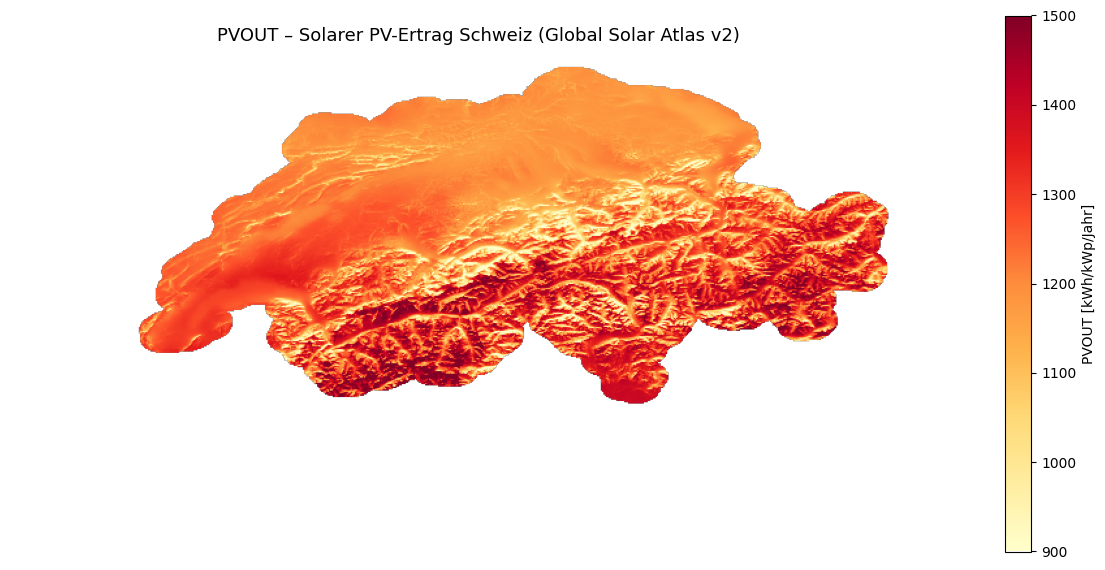

In [176]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
im = plt.imshow(data, cmap='YlOrRd', vmin=900, vmax=1500)
plt.colorbar(im, label='PVOUT [kWh/kWp/Jahr]', shrink=0.8)
plt.title('PVOUT – Solarer PV-Ertrag Schweiz (Global Solar Atlas v2)', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

##4 Werte an bekannten Orten prüfen (Qualitätskontrolle 3)

**Ziel:** Die Rangfolge Lugano > Bern > Basel muss stimmen. Wenn das nicht der Fall ist, wurde vermutlich die falsche Datei geladen.

**Vorgehen:** PVOUT-Pixelwert an drei bekannten Koordinaten ablesen und mit Erwartungswerten vergleichen. Die drei Orte wurden bewusst weit voneinander gewählt, damit der Unterschied auch bei der ~1 km Auflösung klar messbar ist.

**Was der Code macht:**
- `rowcol(transform, lon, lat)` berechnet den Zeilen-/Spalten-Index im Raster für eine geographische Koordinate (Längen- und Breitengrad)
- `src.read(1)[r, c]` liest den Pixelwert an dieser Stelle direkt aus dem Daten-Array
- Am Ende wird automatisch geprüft, ob die Süd-nach-Nord-Rangfolge stimmt

In [177]:
from rasterio.transform import rowcol

prueforte = [
    ('Lugano', 8.96, 46.00, '~1450 – Tessin, sonnigste Grossstadt CH'),
    ('Bern',   7.45, 46.95, '~1150 – Mittelland'),
    ('Basel',  7.59, 47.56, '~1050 – nördlichste Grossstadt'),
]

with rasterio.open(PVOUT_PATH) as src:
    print('{:<10} {:>22}  {}'.format('Ort', 'PVOUT [kWh/kWp/Jahr]', 'Erwartung'))
    print('-' * 65)
    werte = []
    for name, lon, lat, erwartung in prueforte:
        r, c = rowcol(src.transform, lon, lat)
        val = float(src.read(1)[r, c])
        werte.append(val)
        print('{:<10} {:>22.0f}  {}'.format(name, val, erwartung))

rangfolge_ok = all(werte[i] >= werte[i+1] for i in range(len(werte)-1))
print()
if rangfolge_ok:
    print('✓ Rangfolge korrekt (Süd > Nord) – Daten plausibel')
else:
    print('✗ Rangfolge stimmt nicht – Datei prüfen!')

Ort          PVOUT [kWh/kWp/Jahr]  Erwartung
-----------------------------------------------------------------
Lugano                       1367  ~1450 – Tessin, sonnigste Grossstadt CH
Bern                         1258  ~1150 – Mittelland
Basel                        1199  ~1050 – nördlichste Grossstadt

✓ Rangfolge korrekt (Süd > Nord) – Daten plausibel


##5 Gemeindegrenzen der Schweiz laden

**Ziel:** Polygone aller Schweizer Gemeinden laden, damit der PVOUT-Wert pro Gemeinde berechnet werden kann.

**Vorgehen:** Die swissBOUNDARIES3D-Datei (von swisstopo) enthält die offiziellen Gemeindegrenzen. Wir laden den Layer `tlm_hoheitsgebiet`.

**Was der Code macht:**
- Das GPKG wird von der GitHub Raw URL heruntergeladen und auf den lokalen `/content/`-Speicher kopiert. Das ist notwendig, weil `geopandas` `.gpkg`-Dateien nicht direkt von einer URL öffnen kann.
- `engine='fiona'` gibt den korrekten Treiber zum Öffnen von GPKG-Dateien an.
- `to_crs('EPSG:4326')` konvertiert das Koordinatensystem: von Schweizer LV95 (EPSG:2056) zu WGS84 (EPSG:4326) – dem gleichen System wie PVOUT.tif

**Manuelle Plausibilitätsprüfung (Human in the Loop):**
Die Tabelle am Ende zeigt BFS-Nummer, Gemeindename und Kantonnummer. Diese kann mit der offiziellen swisstopo-Übersichtskarte abgeglichen werden:
https://www.swisstopo.admin.ch/de/ubersichtskarten-der-schweiz
Beispiel: BFS-Nr. 261 = Zürich, BFS-Nr. 6621 = Lugano – stimmt das überein?


In [178]:
import geopandas as gpd
import os

# Importiere requests für das Herunterladen von Dateien über HTTP
import requests

GPKG_LOCAL = '/content/swissboundaries.gpkg'

# Überprüfe, ob die Datei bereits lokal existiert. Wenn nicht, lade sie von GitHub herunter.
if not os.path.exists(GPKG_LOCAL):
    print('Lade GPKG von GitHub auf lokalen Speicher...')
    try:
        response = requests.get(GPKG_PATH, stream=True)
        response.raise_for_status() # Löst einen HTTPError für schlechte Statuscodes (4xx oder 5xx) aus
        with open(GPKG_LOCAL, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192): # Lade die Datei in Blöcken herunter
                f.write(chunk)
        print('✓ Heruntergeladen')
    except Exception as e:
        print(f"Fehler beim Herunterladen der GPKG-Datei von {GPKG_PATH}: {e}")
        # Optional: Hier könnte man das Programm beenden oder eine weitere Fehlerbehandlung durchführen
else:
    print('GPKG-Datei bereits lokal vorhanden.')

# Lade die Gemeindegrenzen aus der lokalen GPKG-Datei
gemeinden_geo  = gpd.read_file(GPKG_LOCAL, layer='tlm_hoheitsgebiet', engine='fiona')
gemeinden_wgs84 = gemeinden_geo.to_crs('EPSG:4326')

print(f'Gemeinden geladen : {len(gemeinden_wgs84)}')
print(f'Koordinatensystem : {gemeinden_wgs84.crs}')
gemeinden_wgs84[['bfs_nummer', 'name', 'kantonsnummer']].head(3)

GPKG-Datei bereits lokal vorhanden.
Gemeinden geladen : 2136
Koordinatensystem : EPSG:4326


,bfs_nummer,name,kantonsnummer
0,131,Adliswil,1.0
1,3714,Rheinwald,18.0
2,5722,Grens,22.0


##6 Mittleren PVOUT pro Gemeinde berechnen (Zonale Statistik)

**Ziel:** Für jede der rund 2136 Schweizer Gemeinden den durchschnittlichen PVOUT-Wert berechnen.

**Vorgehen:** Das PVOUT-Raster und die Gemeindegrenzen werden übereinandergelegt. Für jede Gemeinde werden alle darin liegenden Pixel gemittelt.

**Was der Code macht:**
- `zonal_stats()` überlagert Gemeinde-Polygone mit dem PVOUT-Raster
- Für jede Gemeinde werden alle Pixel innerhalb des Polygons gemittelt (`stats=['mean']`)
- `nodata=-9999` teilt dem Algorithmus mit, welcher Wert für «keine Daten» steht
- **Dieser Schritt dauert 1–3 Minuten** – das ist normal bei über 2000 Gemeinden

**Quercheck der Ergebnisse:**  
Das Bundesamt für Statistik (BFS) veröffentlicht Daten zu allen Schweizer Gemeinden:  
https://www.bfs.admin.ch/bfs/en/home/news/whats-new.assetdetail.36390081.html  
Damit lassen sich Gemeindename, BFS-Nummer und Kanton gegenseitig validieren – ein guter Anhaltspunkt, ob die Daten vollständig und korrekt zugeordnet wurden.

In [179]:
from rasterstats import zonal_stats

print('Berechne mittleren PVOUT pro Gemeinde ... (1–3 Minuten)')
stats = zonal_stats(
    gemeinden_wgs84,
    PVOUT_PATH,
    stats=['mean'],
    nodata=-9999
)
print(f'✓ Fertig: {len(stats)} Gemeinden verarbeitet')

Berechne mittleren PVOUT pro Gemeinde ... (1–3 Minuten)
✓ Fertig: 2136 Gemeinden verarbeitet


##7 Ergebnis-Tabelle erstellen

**Ziel:** Die berechneten PVOUT-Werte mit den Gemeindeinformationen in eine übersichtliche Tabelle zusammenführen.

**Vorgehen:** PVOUT-Mittelwert als neue Spalte anfügen, nicht benötigte Spalten entfernen, Kantonsname hinzufügen, Zeilen ohne Wert entfernen.

**Was der Code macht – im Detail:**

**Welche Spalten gibt es im GPKG, und warum werden die meisten nicht verwendet?**  
Der Layer `tlm_hoheitsgebiet` enthält 23 Spalten, darunter: `uuid`, `datum_aenderung`, `datum_erstellung`, `erstellung_jahr`, `erstellung_monat`, `grund_aenderung`, `herkunft`, `revision_jahr`, `revision_qualitaet`, `objektart`, `bezirksnummer`, `gem_flaeche`, `see_flaeche`, `icc`, `shn`, `einwohnerzahl`, `hist_nr` u.v.m.  
Diese Verwaltungs- und Historisierungsfelder brauchen wir für die Analyse nicht. Wir behalten nur 4 inhaltlich relevante Spalten: `bfs_nummer`, `name`, `kantonsnummer` und den berechneten `pvout_kwh_kwp_year`.

**Kantonsname statt Kantonnummer:**  
Das GPKG enthält nur die Kantonnummer (1–26), keinen lesbaren Kantonsnamen. Deshalb wird eine Zuordnungstabelle (`KANTON_NAME`) verwendet, um die Nummer in den deutschen Kantonsnamen umzuwandeln.

**Warum gibt es Zeilen ohne PVOUT-Wert?**  
`zonal_stats()` berechnet den Mittelwert aller Pixel *innerhalb* eines Gemeindepolygons. Bei sehr kleinen Gemeinden (Fläche kleiner als ein Pixel = < 1 km²) liegt kein einziger Pixelmittelpunkt im Polygon. Das Ergebnis für diese Gemeinden ist `None`. `dropna()` entfernt sie. Der Vergleich vor/nach zeigt wie viele das betrifft.

In [180]:
import pandas as pd

# Zuordnung Kantonsnummer (1–26) → deutscher Kantonsname
KANTON_NAME = {
    1: 'Zürich',          2: 'Bern',              3: 'Luzern',
    4: 'Uri',             5: 'Schwyz',             6: 'Obwalden',
    7: 'Nidwalden',       8: 'Glarus',             9: 'Zug',
    10: 'Freiburg',       11: 'Solothurn',         12: 'Basel-Stadt',
    13: 'Basel-Landschaft', 14: 'Schaffhausen',    15: 'Appenzell AR',
    16: 'Appenzell AI',   17: 'St. Gallen',        18: 'Graubünden',
    19: 'Aargau',         20: 'Thurgau',           21: 'Tessin',
    22: 'Waadt',          23: 'Wallis',            24: 'Neuenburg',
    25: 'Genf',           26: 'Jura'
}

gemeinden_wgs84['pvout_kwh_kwp_year'] = [s['mean'] for s in stats]
gemeinden_wgs84['kanton_name'] = gemeinden_wgs84['kantonsnummer'].map(KANTON_NAME)

pvout_gemeinden = gemeinden_wgs84[['bfs_nummer', 'name', 'kanton_name', 'pvout_kwh_kwp_year']].copy()
pvout_gemeinden.columns = ['gemeinde_nr', 'gemeinde_name', 'kanton_name', 'pvout_kwh_kwp_year']

vor_dropna = len(pvout_gemeinden)
pvout_gemeinden = pvout_gemeinden.dropna(subset=['pvout_kwh_kwp_year'])
nach_dropna = len(pvout_gemeinden)

pv_min  = pvout_gemeinden['pvout_kwh_kwp_year'].min()
pv_max  = pvout_gemeinden['pvout_kwh_kwp_year'].max()
pv_mean = pvout_gemeinden['pvout_kwh_kwp_year'].mean()

print(f'Gemeinden total      : {vor_dropna}')
print(f'Ohne PVOUT-Wert      : {vor_dropna - nach_dropna}  (Polygon kleiner als 1 Pixel)')
print(f'Gemeinden mit Daten  : {nach_dropna}')
print(f'PVOUT-Bereich        : {pv_min:.0f} – {pv_max:.0f} kWh/kWp/Jahr')
print(f'Schweizer Mittelwert : {pv_mean:.0f} kWh/kWp/Jahr')
pvout_gemeinden.head(5)

Gemeinden total      : 2136
Ohne PVOUT-Wert      : 4  (Polygon kleiner als 1 Pixel)
Gemeinden mit Daten  : 2132
PVOUT-Bereich        : 885 – 1485 kWh/kWp/Jahr
Schweizer Mittelwert : 1220 kWh/kWp/Jahr


,gemeinde_nr,gemeinde_name,kanton_name,pvout_kwh_kwp_year
0,131,Adliswil,Zürich,1155.791391
1,3714,Rheinwald,Graubünden,1273.649336
2,5722,Grens,Waadt,1292.010905
3,6730,Val Terbi,Jura,1131.424248
4,4123,Windisch,Aargau,1164.307422


##8 Rangliste prüfen (Qualitätskontrolle 4)

**Ziel:** Top- und Bottom-Gemeinden auf Plausibilität prüfen.

**Erwartung:** Walliser und Tessiner Gemeinden ganz oben, nördliche oder schattige Gemeinden ganz unten.

**Was der Code macht:**
- `nlargest(10, ...)` sortiert die Tabelle absteigend und gibt die 10 höchsten Werte zurück
- `nsmallest(10, ...)` gibt die 10 niedrigsten Werte zurück
- So kann man sofort sehen, ob die Daten geografisch sinnvoll sind

In [181]:
print('=== Top 10 – höchster PV-Ertrag ===')
top10 = pvout_gemeinden.nlargest(10, 'pvout_kwh_kwp_year')[['gemeinde_name', 'pvout_kwh_kwp_year']]
print(top10.to_string(index=False))

print()
print('=== Bottom 10 – niedrigster PV-Ertrag ===')
bot10 = pvout_gemeinden.nsmallest(10, 'pvout_kwh_kwp_year')[['gemeinde_name', 'pvout_kwh_kwp_year']]
print(bot10.to_string(index=False))

print()
print('Erwartung: Top = Wallis / Tessin / Graubünden (Südhänge)')
print('           Bottom = nördliche Täler / alpine Schattenlage')

=== Top 10 – höchster PV-Ertrag ===
       gemeinde_name  pvout_kwh_kwp_year
      Guttet-Feschel         1485.263114
       Crans-Montana         1476.687500
                Lens         1473.579219
           Grimisuat         1469.887695
               Arbaz         1469.589214
               Varen         1465.632102
          Ausserberg         1461.949531
       Noble-Contrée         1435.797656
            Orselina         1430.684082
Brione sopra Minusio         1426.788411

=== Bottom 10 – niedrigster PV-Ertrag ===
 gemeinde_name  pvout_kwh_kwp_year
      Därligen          884.726888
      Emmetten          957.074139
       Bönigen          958.640700
    Wilderswil          960.059482
     Rongellen          973.573975
     Leissigen          980.889706
Hergiswil (NW)          994.655762
     Iseltwald         1000.370355
    Schattdorf         1001.553341
  Seedorf (UR)         1002.156597

Erwartung: Top = Wallis / Tessin / Graubünden (Südhänge)
           Bottom = nördlic

##9 Choropleth-Karte – PVOUT pro Gemeinde

**Ziel:** Alle Gemeinden auf einer Karte anzeigen, eingefärbt nach ihrem mittleren PVOUT-Wert.

**Vorgehen:** Jedes Gemeinde-Polygon wird entsprechend dem berechneten Mittelwert eingefärbt.

**Was der Code macht:**
- `geopandas.plot(column='pvout_kwh_kwp_year', cmap='YlOrRd')` zeichnet die Choropleth-Karte
- Grau = Gemeinden ohne berechneten PVOUT-Wert (sehr klein oder am Rand)
- Die Legende rechts erklärt die Farbskala in kWh/kWp/Jahr
- Diese Karte ist hochauflösender als die Pixel-Karte aus Schritt 4, da hier Gemeindepolygone verwendet werden

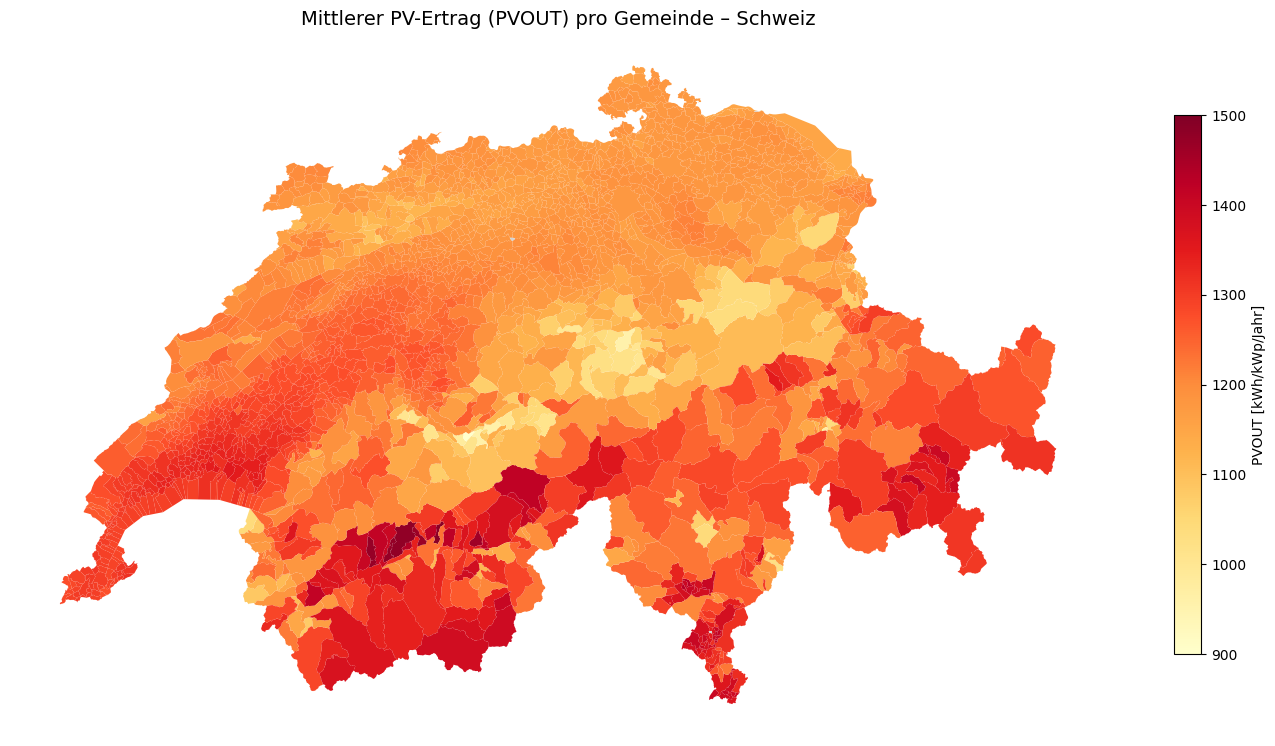

In [182]:
fig, ax = plt.subplots(figsize=(14, 8))
gemeinden_wgs84.plot(
    column='pvout_kwh_kwp_year',
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': 'PVOUT [kWh/kWp/Jahr]', 'shrink': 0.7},
    ax=ax,
    missing_kwds={'color': 'lightgrey', 'label': 'keine Daten'},
    vmin=900,
    vmax=1500
)
ax.set_title('Mittlerer PV-Ertrag (PVOUT) pro Gemeinde – Schweiz', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

##10 Ergebnis als CSV speichern

**Ziel:** Die berechneten PVOUT-Werte für alle Gemeinden speichern, damit Notebook 3 (Auswertung) sie direkt laden kann – ohne die lange Berechnung nochmals durchführen zu müssen.

**Was der Code macht:**
- Der Speicherpfad wird automatisch berechnet: zwei Ordner-Ebenen über PVOUT.tif (also im Daten-Stammordner)
- Die CSV enthält 4 Spalten: `gemeinde_nr`, `gemeinde_name`, `kanton_name`, `pvout_kwh_kwp_year`
- `index=False` verhindert, dass pandas eine zusätzliche Zeilennummer-Spalte hinzufügt

**Hinweis zur Zeilenanzahl:**  
Die CSV enthält 2132 statt 2136 Zeilen, weil in Schritt 8 vier Gemeinden ohne PVOUT-Wert entfernt wurden. Diese vier Gemeinden sind kleiner als 1 km² und haben kein einziges Rasterpixel in ihrem Polygon.

In [183]:
# Speichere die CSV-Datei lokal im Colab-Dateisystem
output_path = '/content/pvout_gemeinden.csv'

pvout_gemeinden.to_csv(output_path, index=False)
print(f'✓ Gespeichert : {output_path}')
print(f'  {len(pvout_gemeinden)} Zeilen | Spalten: {list(pvout_gemeinden.columns)}')
print('\nDie Datei wurde lokal in Colab gespeichert. Du kannst sie über das Dateisymbol links herunterladen und dann manuell in dein GitHub-Repository hochladen.')

✓ Gespeichert : /content/pvout_gemeinden.csv
  2132 Zeilen | Spalten: ['gemeinde_nr', 'gemeinde_name', 'kanton_name', 'pvout_kwh_kwp_year']

Die Datei wurde lokal in Colab gespeichert. Du kannst sie über das Dateisymbol links herunterladen und dann manuell in dein GitHub-Repository hochladen.


---

##11 Adresse eingeben

**Ziel:** Eine konkrete Schweizer Adresse angeben, für die der PVOUT-Wert abgefragt werden soll.

**Vorgehen:** Einfach die Adresse in der Variable `ADRESSE` anpassen und danach Schritt 13 ausführen.

**Tipps:**
- Am besten immer Ort und «Schweiz» anhängen: `Hauptstrasse 1, Bern, Schweiz`
- Zum Vergleich lohnt sich eine sonnige Bergadresse, z.B. `Täsch, Schweiz` (Mattertal, Südexposition)
- Im flachen Mittelland sind Nachbarpixel ähnlich – das ist physikalisch korrekt, kein Fehler

In [184]:
# <- HIER ADRESSE ANPASSEN (dann Schritt 13 ausführen)
ADRESSE = 'Bundesplatz 3, Bern, Schweiz'

# Testadressen zum Vergleich:
# ADRESSE = 'Lugano, Schweiz'         # sehr sonnig, Tessin
# ADRESSE = 'Täsch, Schweiz'          # sonnig, Südexposition Mattertal
# ADRESSE = 'Randa, Schweiz'          # weniger sonnig, Schattental
# ADRESSE = 'Zürich, Schweiz'         # typisches Mittelland

##12 PVOUT-Wert und Gemeinde für die eingegebene Adresse abfragen

**Ziel:** Für die oben eingegebene Adresse den PVOUT-Pixelwert und die zugehörige Gemeinde ausgeben.

**Vorgehen:** Drei Teilschritte:
1. **Adresse → Koordinaten** – swisstopo API als Hauptquelle (kennt alle offiziellen Schweizer Adressen), Nominatim als Fallback
2. **Koordinaten → PVOUT-Pixelwert** – rasterio liest den nächsten Pixel aus PVOUT.tif
3. **Koordinaten → Gemeinde** – Spatial Join: der Punkt wird einem Gemeinde-Polygon zugeordnet

**Hinweis zur Auflösung:**  
Die Datei hat eine Auflösung von ca. 1 km × 1 km pro Pixel. Zwei Adressen im gleichen Quartier können denselben Pixelwert haben – das ist ein Auflösungseffekt der Datenquelle, kein Fehler. Im Mittelland sind auch Nachbarpixel ähnlich (kaum Topografie). Grössere Unterschiede zeigen sich in Bergregionen: Nord- vs. Südhang können 30–40 % auseinanderliegen.

In [185]:
import requests
from geopy.geocoders import Nominatim
from shapely.geometry import Point

def geocodiere_adresse(adresse):
    # Primär: swisstopo API (kennt alle offiziellen CH-Adressen aus dem Gebäuderegister)
    try:
        url = 'https://api3.geo.admin.ch/rest/services/api/SearchServer'
        params = {'type': 'locations', 'searchText': adresse, 'limit': 1, 'sr': '4326'}
        r = requests.get(url, params=params, timeout=10)
        results = r.json().get('results', [])
        if results:
            attrs = results[0]['attrs']
            return attrs['lat'], attrs['lon'], attrs.get('label', adresse), 'swisstopo'
    except Exception:
        pass
    # Fallback: Nominatim / OpenStreetMap
    try:
        gc = Nominatim(user_agent='bina-pv-projekt')
        ort = gc.geocode(adresse)
        if ort:
            return ort.latitude, ort.longitude, ort.address, 'Nominatim'
    except Exception:
        pass
    return None, None, None, None


# 1. Adresse geocodieren
lat, lon, gefunden, quelle = geocodiere_adresse(ADRESSE)

if not lat:
    print(f'Adresse nicht gefunden: {ADRESSE}')
    print('Tipp: Ort und "Schweiz" anfügen, z.B. "Hauptstrasse 1, Bern, Schweiz"')
else:
    print(f'Geocoding ({quelle}): {gefunden}')
    print(f'Koordinaten: {lat:.5f}°N, {lon:.5f}°E')

    # 2. PVOUT-Pixelwert lesen
    with rasterio.open(PVOUT_PATH) as src:
        r, c = rowcol(src.transform, lon, lat)
        pvout_wert = float(src.read(1)[r, c])
    print()
    print(f'PVOUT: {pvout_wert:.0f} kWh/kWp/Jahr')

    # 3. Gemeinde via Spatial Join ermitteln
    punkt = gpd.GeoDataFrame(geometry=[Point(lon, lat)], crs='EPSG:4326')
    treffer = gpd.sjoin(punkt, gemeinden_wgs84[['bfs_nummer', 'name', 'geometry']], how='left', predicate='within')
    if len(treffer) > 0 and not treffer['name'].isna().all():
        gname = treffer['name'].values[0]
        gnr   = int(treffer['bfs_nummer'].values[0])
        print(f'Gemeinde: {gname} (BFS-Nr: {gnr})')
    else:
        print('Gemeinde: nicht ermittelbar')

    print()
    print('=' * 45)
    print(f'Adresse : {ADRESSE}')
    print(f'PVOUT   : {pvout_wert:.0f} kWh/kWp/Jahr')
    print('=' * 45)

Geocoding (swisstopo): Bundesplatz 3 <b>3011 Bern</b>
Koordinaten: 46.94677°N, 7.44419°E

PVOUT: 1254 kWh/kWp/Jahr
Gemeinde: Bern (BFS-Nr: 351)

Adresse : Bundesplatz 3, Bern, Schweiz
PVOUT   : 1254 kWh/kWp/Jahr
